## Import Modules

In [35]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image
from dotenv import load_dotenv
from groq import Groq
from langchain_groq import ChatGroq

load_dotenv()


True

In [24]:
client = Groq(api_key=GROQ_API_KEY)

In [36]:
llm = ChatGroq(model="openai/gpt-oss-120b")

## Simple Sequential Work Flow

In [3]:
# define state
class BMIState(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [4]:
def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)

    return state

In [5]:
def label_bmi(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [6]:
# define your graph
graph = StateGraph(BMIState)

# add nodes to your graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# add edges to your graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)


# compile the graph
workflow = graph.compile()

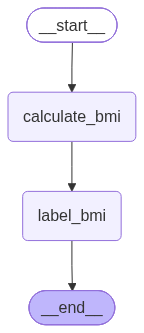

In [8]:
Image(workflow.get_graph().draw_mermaid_png())

In [10]:
# execute the graph
intial_state = {'weight_kg':80, 'height_m':1.73}

final_state = workflow.invoke(intial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


## LLM workflow

In [12]:
class LLMState(TypedDict):
    '''
    
    '''
    question: str
    answer: str

In [37]:
def llm_qa(state: LLMState) -> LLMState:
    question = state['question']

    # Here you would call your LLM API to get the answer
    # For demonstration, we'll just return a dummy answer
    prompt = f" answer to the question: {question}"

    # print("heello")
    
    answer = llm.invoke(prompt).content  # This is a placeholder for the actual LLM call

    state['answer'] = answer

    return state

In [38]:
graph = StateGraph(LLMState)

graph.add_node("llm_qa",llm_qa)

# add edges to your graph
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

workflow = graph.compile()

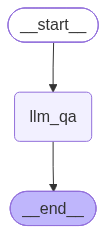

In [39]:
Image(workflow.get_graph().draw_mermaid_png())

In [40]:
## execute the graph
intial_state = {'question': "What is the capital of France?"}
workflow.invoke(intial_state)

{'question': 'What is the capital of France?',
 'answer': 'The capital of France is **Paris**.'}

In [43]:
## execute the graph
intial_state = {'question': "What is the capital of France?"}
output = workflow.invoke(intial_state)
output["answer"]

'The capital of France is **Paris**.'

## Prompt Chaining

In [44]:
## define State

class BlogState(TypedDict):

    title: str
    outline: str
    content: str
    

In [ ]:
def generate_outline(state: BlogState) -> BlogState:
    title = state['title']

    prompt = f"Generate a detailed outline for a blog post titled: {title}"

    outline = llm.invoke(prompt).content  # This is a placeholder for the actual LLM call

    state['outline'] = outline

    return state

In [46]:
def generate_content(state: BlogState) -> BlogState:
    outline = state['outline']

    prompt = f"Generate content for the following outline: {outline}"

    content = llm.invoke(prompt).content  # This is a placeholder for the actual LLM call

    state['content'] = content

    return state

In [47]:
graph = StateGraph(BlogState)

graph.add_node("generate_outline", generate_outline)
graph.add_node("generate_content", generate_content)

graph.add_edge(START, 'generate_outline')
graph.add_edge('generate_outline', 'generate_content')
graph.add_edge('generate_content', END)

workflow = graph.compile()

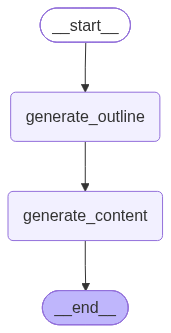

In [48]:
Image(workflow.get_graph().draw_mermaid_png())

In [49]:
intial_state = {'title': "The Future of AI in Healthcare"}
output = workflow.invoke(intial_state)
output

{'title': 'The Future of AI in Healthcare',
 'outline': '**Blog Post Outline: “The Future of AI in Healthcare”**\n\n---\n\n### 1. Introduction  \n- **Hook:** A compelling statistic or anecdote (e.g., “AI‑driven diagnostics are already detecting certain cancers with 99% accuracy.”)  \n- **Why it matters:** Briefly explain the stakes—rising costs, aging populations, and the need for faster, more precise care.  \n- **Thesis statement:** Preview the key ways AI will reshape healthcare over the next decade.\n\n---\n\n### 2. Current Landscape: Where AI Stands Today  \n- **Diagnostics & Imaging** – radiology, pathology, dermatology AI tools.  \n- **Predictive Analytics** – risk scoring, early‑warning systems for sepsis, readmission.  \n- **Administrative Automation** – claim processing, scheduling, billing.  \n- **Patient‑Facing Applications** – chatbots, symptom checkers, wearable data analysis.  \n- **Brief success stories** (e.g., IBM Watson Oncology, Google DeepMind’s eye‑disease model).\

In [50]:
output["outline"]

'**Blog Post Outline: “The Future of AI in Healthcare”**\n\n---\n\n### 1. Introduction  \n- **Hook:** A compelling statistic or anecdote (e.g., “AI‑driven diagnostics are already detecting certain cancers with 99% accuracy.”)  \n- **Why it matters:** Briefly explain the stakes—rising costs, aging populations, and the need for faster, more precise care.  \n- **Thesis statement:** Preview the key ways AI will reshape healthcare over the next decade.\n\n---\n\n### 2. Current Landscape: Where AI Stands Today  \n- **Diagnostics & Imaging** – radiology, pathology, dermatology AI tools.  \n- **Predictive Analytics** – risk scoring, early‑warning systems for sepsis, readmission.  \n- **Administrative Automation** – claim processing, scheduling, billing.  \n- **Patient‑Facing Applications** – chatbots, symptom checkers, wearable data analysis.  \n- **Brief success stories** (e.g., IBM Watson Oncology, Google DeepMind’s eye‑disease model).\n\n---\n\n### 3. Pillars of Future Growth  \n\n#### 3.1.

In [53]:
for i in output["content"].split("/n"):
    print(i)

**The Future of AI in Healthcare**  
*How intelligent machines are poised to transform diagnosis, treatment, and the very way we think about health over the next decade.*

---

## 1. Introduction  

**Hook:** *“AI‑driven diagnostics are already detecting certain cancers with 99% accuracy.”*  
That figure isn’t a futuristic fantasy—it’s the reality of several FDA‑cleared tools that are already in the clinic today.  

**Why it matters:**  
- **Rising costs:** The U.S. alone spends more than **$4 trillion** on health care each year, and that number is climbing faster than GDP.  
- **Aging populations:** By 2035, one in five Americans will be over 65, straining hospitals and long‑term‑care facilities.  
- **Speed & precision:** Patients and providers need faster, more accurate insights to avoid misdiagnoses, reduce readmissions, and deliver truly personalized care.  

**Thesis statement:** In the coming decade AI will reshape health care across five pillars—precision medicine, real‑time de